# [Practice] Sampling Theory: 표본과 분포

### [Contents]
1. 대수의 법칙
2. 제곱근의 법칙
3. 중심극한정리
4. 정규분포

### [Note]  

각 실습은 다음 순서로 구성되어 있음  

1. Question : 무엇을 확인할 것인가?
2. Expectation : 실행 전 예상
3. Code Run : 코드 실행
4. Result : 실행 결과
5. Interpretation : 결과의 통계적 해석
6. AI Application : AI/모델 평가와의 연결  
  
<br>    

실습 진행은 다음의 순서로 진행  
1. 개인 작업: 각자 실습을 실행하고, 통계적 해석과 AI 활용 연결에 대한 자신의 생각을 먼저 정리
   
2. 조별 토의: 개인 해석을 조원들과 공유하고, 서로 다른 관점이 있다면 그 차이가 어디서 비롯되는지 논의  


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

Matplotlib is building the font cache; this may take a moment.


# 1. 대수의 법칙

### 1) Question
주사위 시행 횟수가 증가하면 숫자 1의 비율은 이론적 확률 1/6에 가까워지는가?

### 2) Expectation

실행 전 예상 결과를 작성할 것.

- 예상:
> 시행 횟수가 적을 때(10회)는 1이 나온 비율이 이론값 1/6(≈0.167)에서 크게 벗어나겠지만, 시행이 많아질수록(10,000회) 관측 비율이 0.167에 가까워질 것이다.

### 3) Code Run

In [5]:
sample_sizes = [10, 100, 1_000, 10_000]
results = []

for n in sample_sizes:
    dice = np.random.randint(1, 7, size=n)
    ratio = np.mean(dice == 1)   ### 확인하려는 눈금을 채우시오

    results.append([n, ratio])

result_df = pd.DataFrame(
    results,
    columns=["Sample Size", "Observed Probability"]
)

result_df

,Sample Size,Observed Probability
0,10,0.0000
1,100,0.1600
2,1000,0.1800
3,10000,0.1683


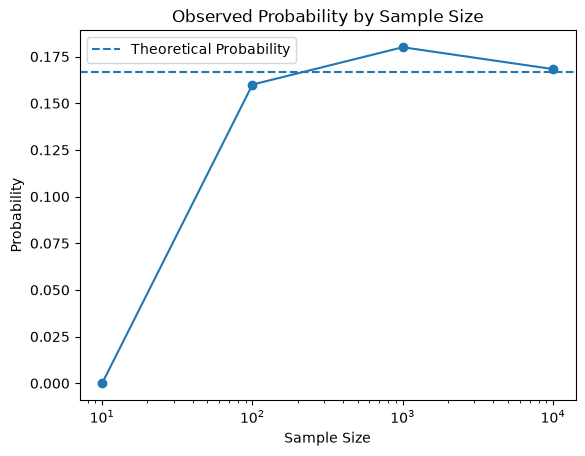

In [6]:
plt.plot(
    result_df["Sample Size"],
    result_df["Observed Probability"],
    marker="o"
)
plt.axhline(
    1/6,
    linestyle="--",
    label="Theoretical Probability"
)
plt.xscale("log")
plt.xlabel("Sample Size")
plt.ylabel("Probability")
plt.title("Observed Probability by Sample Size")
plt.legend()
plt.show()

### 4) Result

그래프에서 확인한 결과를 작성할 것.

- 결과:
> **[작성]** 표본 10에서는 관측 확률이 0.0으로 이론값에서 크게 벗어났고, 100에서 0.16, 1,000에서 0.18로 변동하다가 10,000에서 0.168로 이론값 0.167에 거의 수렴했다. 로그 스케일 그래프에서 표본이 커질수록 점선(이론 확률)에 수렴하는 모습이 뚜렷하다.

### 5) Interpretation

- 시행 횟수가 증가하면서 어떤 변화가 나타났는가?
- 소표본 결과의 변동이 큰 이유는 무엇인가?
> **[작성]** 시행 횟수가 증가하면서 관측 확률의 변동 폭이 줄고 이론값 1/6에 안정적으로 수렴했다(대수의 법칙). 소표본은 표본 하나하나가 전체 비율에 미치는 영향이 커서, 우연히 1이 안 나오거나 몰려 나오면 비율이 크게 튄다. 표본이 커지면 이런 우연이 평균화되어 참값이 드러난다.

### 6) AI Application

평가 데이터가 적을 때 AI 모델의 정확도가 불안정한 이유는 무엇일까?
> **[작성]** 평가 데이터가 적으면 소수 샘플의 정오답이 정확도에 큰 영향을 주므로, 우연히 쉬운/어려운 샘플이 뽑히면 성능이 실제보다 과대·과소평가된다. 대수의 법칙에 따라 평가셋이 클수록 측정된 정확도가 모델의 참 성능에 수렴해 신뢰할 수 있다. 그래서 소규모 테스트셋의 점수는 변동이 커 재현성이 낮다.

# 2. 제곱근의 법칙

### 1) Question
표본 크기를 4배로 늘리면 표준오차는 절반으로 줄어드는가?

### 2) Expectation

실행 전 예상 결과를 작성할 것.

- 예상:
> **[작성]** 표준오차(SE = σ/√n)는 표본 크기 n의 제곱근에 반비례하므로, n이 4배가 되면 SE는 1/2로 줄 것으로 예상한다. 경험적 표준오차(반복 실험으로 구한 값)도 이론적 표준오차와 거의 일치할 것이다.

### 3) Code Run

In [7]:
sample_sizes = [10, 40, 100, 400, 1_000]
population_mean = 50
population_std = 10
num_experiments = 2_000

results = []

for n in sample_sizes:
    sample_means = []

    for _ in range(num_experiments):
        sample = np.random.normal(
            population_mean,
            population_std,
            size=n
        )
        sample_means.append(sample.mean())

    empirical_se = np.std(sample_means, ddof=1)
    theoretical_se = population_std / np.sqrt(n)   ### 표본 크기를 채우시오

    results.append([
        n,
        empirical_se,
        theoretical_se
    ])

se_df = pd.DataFrame(
    results,
    columns=[
        "Sample Size",
        "Empirical SE",
        "Theoretical SE"
    ]
)

se_df

,Sample Size,Empirical SE,Theoretical SE
0,10,3.143341,3.162278
1,40,1.606107,1.581139
2,100,0.987310,1.000000
3,400,0.503311,0.500000
4,1000,0.313525,0.316228


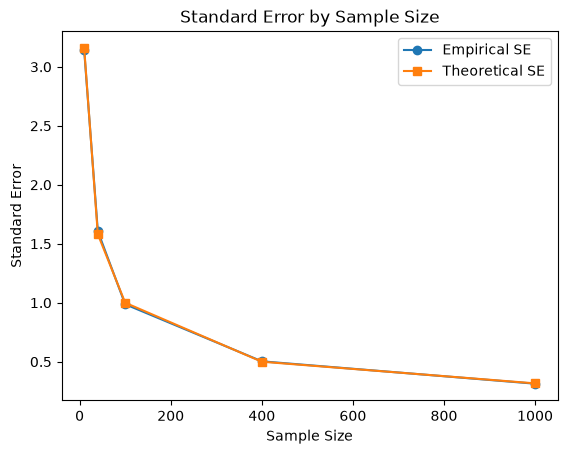

In [8]:
plt.plot(
    se_df["Sample Size"],
    se_df["Empirical SE"],
    marker="o",
    label="Empirical SE"
)
plt.plot(
    se_df["Sample Size"],
    se_df["Theoretical SE"],
    marker="s",
    label="Theoretical SE"
)
plt.xlabel("Sample Size")
plt.ylabel("Standard Error")
plt.title("Standard Error by Sample Size")
plt.legend()
plt.show()

### 4) Result

표본 크기별 표준오차 변화를 작성할 것.

- 결과:
> **[작성]** 표본 크기가 10 → 40 → 100 → 400 → 1,000으로 커질수록 표준오차가 단조 감소했다. 모표준편차 10 기준으로 n=10에서 SE≈3.16, n=40에서 ≈1.58, n=100에서 ≈1.0, n=400에서 ≈0.5로, n이 4배가 될 때마다 SE가 약 절반으로 줄었다. 경험적 SE와 이론적 SE 두 곡선이 거의 겹쳤다.

### 5) Interpretation

- 표본 크기가 4배가 되면 표준오차는 어떻게 변하는가?
- 오차를 1/3로 줄이려면 표본 크기는 몇 배가 되어야 하는가?
> **[작성]** 표본 크기가 4배가 되면 √4=2이므로 표준오차는 1/2로 줄어든다. 오차를 1/3로 줄이려면 √n이 3배가 되어야 하므로 표본 크기는 3²=9배가 필요하다. 즉 오차는 표본 크기의 제곱근에 반비례하며, 정확도를 높일수록 필요한 데이터 양이 제곱으로 급증한다.

### 6) AI Application

AI 모델 평가의 오차를 줄이기 위해 많은 데이터가 필요한 이유는? 데이터를 얼마나 확보해야 할까?
> **[작성]** 평가 지표의 표준오차도 √n에 반비례하므로, 오차를 절반으로 줄이려면 평가 데이터를 4배, 1/3로 줄이려면 9배 확보해야 한다. 초반에는 데이터를 조금만 늘려도 오차가 크게 줄지만, 일정 수준 이후에는 개선 폭이 급격히 둔해진다(수확 체감). 따라서 목표 신뢰수준에 맞춰 필요한 최소 표본 크기를 역산해 확보하는 것이 효율적이다.

# 3. 중심극한정리

### 1) Question
원자료가 치우친 분포여도 표본평균의 분포는 정규분포에 가까워지는가?

### 2) Expectation

실행 전 예상 결과를 작성할 것.

- 예상:
> **[작성]** 원자료가 지수분포(오른쪽으로 크게 치우친 분포)이므로 표본 크기 n=1일 때는 표본평균의 분포도 치우쳐 있을 것이다. 그러나 n이 커질수록(30, 100) 표본평균의 분포가 좌우대칭 종 모양(정규분포)에 가까워지고 퍼짐도 좁아질 것으로 예상한다.

### 3) Code Run

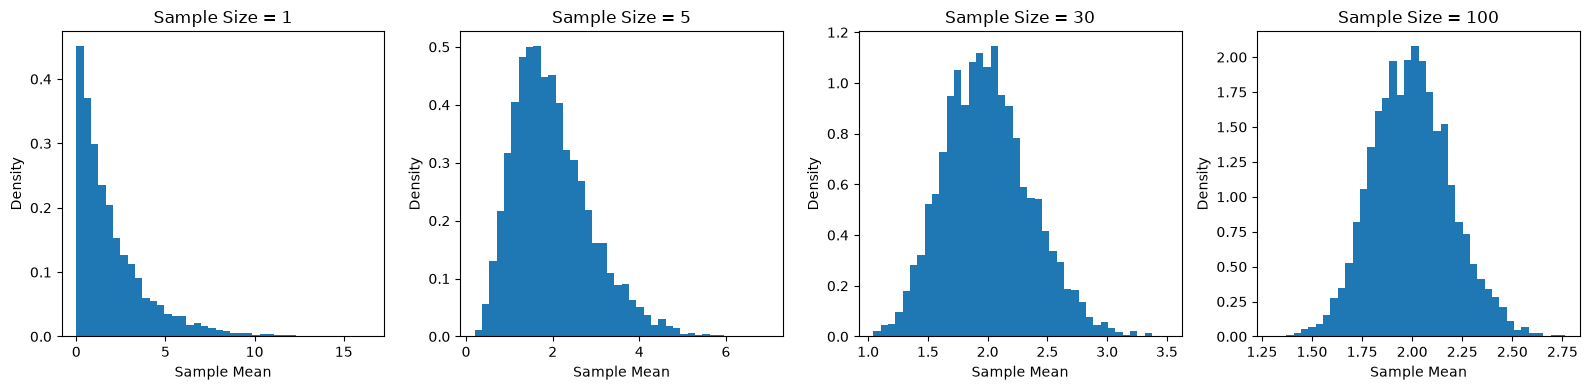

In [9]:
sample_sizes = [1, 5, 30, 100]
num_experiments = 5_000

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n in zip(axes, sample_sizes):
    sample_means = []

    for _ in range(num_experiments):
        sample = np.random.exponential(scale=2, size=n)
        sample_means.append(sample.mean())   # 표본의 평균을 채우시오

    ax.hist(
        sample_means,
        bins=40,
        density=True
    )
    ax.set_title(f"Sample Size = {n}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### 4) Result

n=1과 n=100의 분포 차이를 작성할 것.

- 결과:
> **[작성]** n=1에서는 표본평균 분포가 원자료인 지수분포 그대로 왼쪽에 몰리고 오른쪽 꼬리가 긴 비대칭 형태였다. n=5에서 이미 어느 정도 대칭에 가까워졌고, n=30·100에서는 좌우대칭 종 모양(정규분포)으로 바뀌었으며 분포의 폭(퍼짐)도 크게 좁아졌다.

### 5) Interpretation

표본 크기가 증가하면서 분포의 모양과 퍼짐은 어떻게 달라지는가?
> **[작성]** 원분포가 비대칭이어도 표본 크기가 커질수록 표본평균의 분포는 정규분포에 수렴한다(중심극한정리). 모양은 치우친 형태에서 좌우대칭 종 모양으로 바뀌고, 퍼짐(표준오차)은 √n에 반비례해 점점 좁아진다. 즉 표본평균은 원분포와 무관하게 평균 근처에 정규분포로 집중된다.

### 6) AI Application

중심극한정리는 AI 모델의 반복 평가와 어떤 관련이 있는가?
> **[작성]** 모델을 서로 다른 시드·서로 다른 표본으로 여러 번 반복 평가해 얻은 성능 점수들의 평균은, 원래 점수 분포가 어떤 모양이든 중심극한정리에 의해 정규분포를 따른다. 덕분에 평균 성능에 대해 신뢰구간(예: 정확도 87% ± 1.5%)을 계산할 수 있고, 두 모델의 성능 차이가 우연인지 통계적으로 유의한지 검정할 수 있다. 단일 평가값은 뽑힌 표본에 따라 크게 흔들리지만, 반복 평가의 평균은 정규분포로 좁게 모이므로 훨씬 신뢰할 수 있는 성능 추정치가 된다.

# 4. 정규분포와 이상치 탐지

### 1) Question
평균 200ms, 표준편차 20ms인 응답시간에서 270ms는 이상치로 볼 수 있는가?

### 2) Expectation

실행 전 예상 결과를 작성할 것.

- 예상:
> **[작성]** 평균 200ms, 표준편차 20ms인 정규분포에서 270ms는 z=(270-200)/20=3.5로 평균에서 3.5 표준편차 떨어져 있어, |z|≥2와 |z|≥3 두 기준 모두에서 이상치로 판정될 것으로 예상한다. 180·215·240ms는 평균에 가까워 대부분 정상으로 판정될 것이다.

### 3) Code Run

In [10]:
mean_time = 200
std_time = 20
response_times = np.array([180, 215, 240, 270])

z_scores = (response_times - mean_time) / std_time   ### 표준편차로 나누어 표준화하시오

normal_df = pd.DataFrame({
    "Response Time": response_times,
    "Z-Score": z_scores,
    "Outlier at |z| >= 2": np.abs(z_scores) >= 2,
    "Outlier at |z| >= 3": np.abs(z_scores) >= 3
})

normal_df

,Response Time,Z-Score,Outlier at |z| >= 2,Outlier at |z| >= 3
0,180,-1.00,False,False
1,215,0.75,False,False
2,240,2.00,True,False
3,270,3.50,True,True


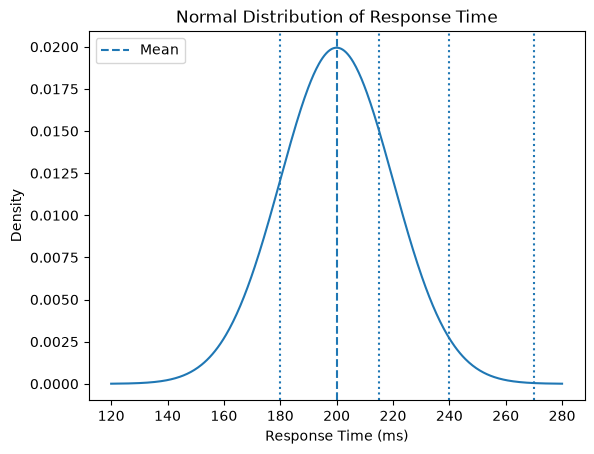

In [11]:
x = np.linspace(
    mean_time - 4 * std_time,
    mean_time + 4 * std_time,
    500
)
y = stats.norm.pdf(
    x,
    mean_time,
    std_time
)

plt.plot(x, y)
plt.axvline(
    mean_time,
    linestyle="--",
    label="Mean"
)

for value in response_times:
    plt.axvline(
        value,
        linestyle=":"
    )

plt.xlabel("Response Time (ms)")
plt.ylabel("Density")
plt.title("Normal Distribution of Response Time")
plt.legend()
plt.show()

### 4) Result

표에 나타난 4개 응답시간(180, 215, 240, 270ms)의 z-score와 이상치 판정 결과를 작성할 것.
> **[작성]**
> - 180ms → z=-1.0 : |z|≥2 정상, |z|≥3 정상
> - 215ms → z=+0.75 : 정상, 정상
> - 240ms → z=+2.0 : |z|≥2 **이상치**, |z|≥3 정상 (경계값)
> - 270ms → z=+3.5 : |z|≥2 **이상치**, |z|≥3 **이상치**
>
> 270ms만 두 기준 모두에서 이상치이고, 240ms는 기준을 2로 잡느냐 3으로 잡느냐에 따라 판정이 갈린다.

### 5) Interpretation

- 240ms는 |z| 기준을 2로 잡을 때와 3으로 잡을 때 판정이 다르다.
- 이처럼 경계에 있는 값을 어떻게 다루는 것이 좋은가?
> **[작성]** 240ms는 z=2.0으로 |z|≥2 기준에서는 이상치, |z|≥3 기준에서는 정상이 된다. 기준(임계값)을 낮게 잡으면 이상치를 더 많이 잡아내지만 정상을 이상치로 오판(거짓 양성)할 위험이 커지고, 높게 잡으면 놓치는 이상치(거짓 음성)가 늘어난다. 따라서 경계값은 도메인의 위험 비용을 고려해 임계값을 정하고, 단일 컷오프로 단정하기보다 경보 후 재확인·다른 지표와 교차검증하는 방식이 안전하다.

### 6) AI Application

이상치 탐지가 활용될 수 있는 AI 분야를 한 가지 선택해보세요. 그 분야에서는 240ms 같은 "경계에 있는 값"을 이상치로 판정하는 것과 정상으로 판정하는 것 중 어느 쪽의 실수가 더 치명적일지, 그 이유를 설명해보세요.
> **[작성]** 분야: 증권 거래 시스템·티켓팅처럼 특정 시각에 트래픽이 몰리는 서비스의 응답시간 모니터링(AIOps).
>
> 이런 시스템은 증권 장 시작(9시)이나 티켓 오픈 순간처럼 동시접속자가 폭증하는 구간이 있는데, 이때의 지연은 사실 매번 반복되는 예측 가능한 정상 부하다. 그래서 평상시 기준(평균 200ms, |z|≥2)을 그대로 쓰면 240ms 같은 값이 피크마다 이상치로 잡혀 거짓 양성(오탐)이 쏟아진다.
>
> 어느 실수가 더 치명적인지는 시간대에 따라 뒤바뀐다. 평상시에는 240ms를 이상치로 보는 거짓 양성이 더 문제다(알람 피로 → 진짜 경보 무시). 반면 피크 구간에서는 240ms를 정상으로 흘려보내는 거짓 음성이 더 치명적이다 — 이 구간의 지연은 주문 체결 지연·예매 실패로 직결되고, 초기 대응이 늦으면 큐 적체·타임아웃으로 연쇄 악화되어 장애로 번지기 때문이다.
>
> 따라서 고정 임계값 하나로는 부족하고, 시간대별로 기준선(baseline)을 다르게 학습하는 동적 임계값이 필요하다. 피크의 정상적 지연은 오탐으로 잡지 않으면서, 그 시간대 기준으로도 벗어나는 진짜 비정상은 놓치지 않게 하는 것이 핵심이다.